#### Librerias

In [127]:
'''DATOS'''
import pandas as pd
import numpy as np
from utils import guardar_grafico, cargar_pickle
from sklearn.cluster import KMeans
import scipy.stats as stats

'''GRAFICOS'''
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter, StrMethodFormatter # Para dar formato a los ejes de los gráficos
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

#### Carga de DF

In [128]:
usuarios = cargar_pickle('usuarios.pkl')
consumo = cargar_pickle('consumo.pkl')
influencia = cargar_pickle('influencia.pkl')
informado = cargar_pickle('informado.pkl')
clusters = cargar_pickle('clusters.pkl')
pca = cargar_pickle('pca.pkl')
tab_certiticaciones = cargar_pickle('tab_cert.pkl')
tab_criterios = cargar_pickle('tab_criterios.pkl')


### Gráficos

In [129]:
font_title={
    'family': 'serif',
    'color':  'darkslategray',
    'weight': 'normal',
    'size': 12,
    }

font_ax={
    'color':  'slategray',
    'weight': 'normal',
    'size': 10,
    }
palette_proyecto = ['darkseagreen','khaki','darkgray','lightgray','teal','darkkhaki','rosybrown','slategray','powderblue','palegoldenrod','mediumaquamarine']

color_heatmap = LinearSegmentedColormap.from_list(
    "color_heatmap",
    ["darkslategray", "white", "darkslategray"]
)
color_perfiles = {'Pragmático':'darkseagreen','Exigente':'khaki','Informado':'powderblue'}

colores_preferencia = {'Dermo':'teal','Lujo':'darkkhaki','Natural':'rosybrown','Trendy':'slategray'}


#### EDA (análisis exploratorio)

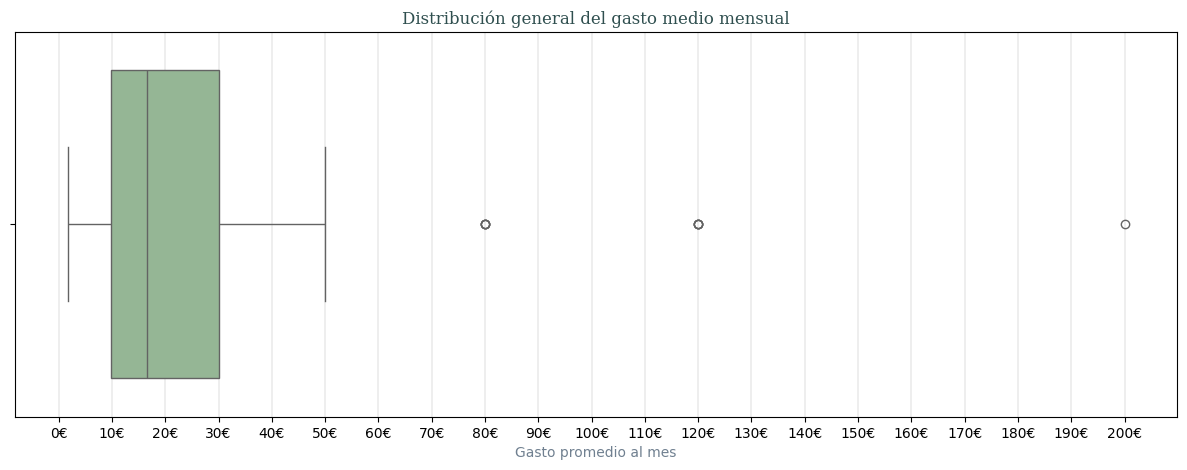

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\dist_gasto_avg.jpg


In [130]:
fig, ax = plt.subplots(figsize=(15, 5)) 
ax.grid(True, linewidth=0.3)
sns.boxplot(
    x='gasto_mensual_avg',
    data=consumo,
    color='darkseagreen'
)
ax.set_title('Distribución general del gasto medio mensual', fontdict=font_title)
ax.set_xlabel('Gasto promedio al mes', fontdict=font_ax)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}€'.replace(',','.')))
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.show()
guardar_grafico(fig,'dist_gasto_avg')

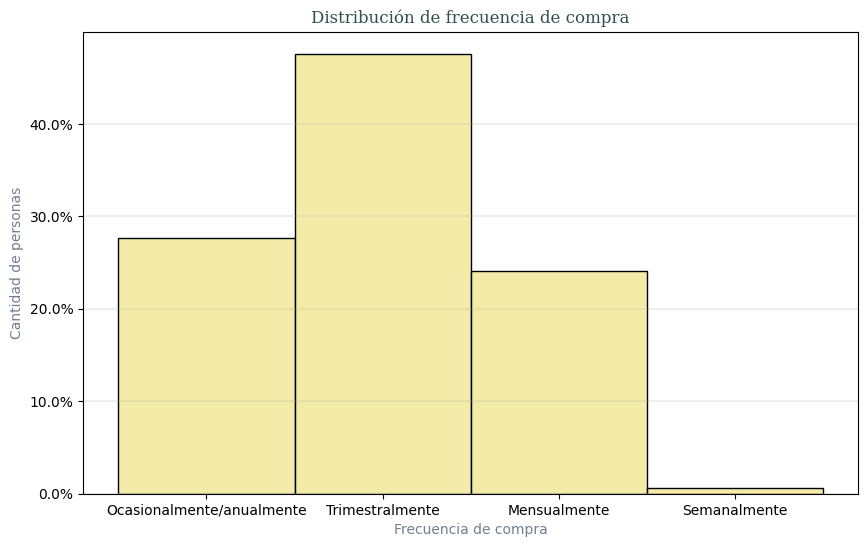

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\dist_frecuencia.jpg


In [131]:

fig, ax = plt.subplots(figsize=(10, 6)) 
sns.histplot(x='frecuencia', data=usuarios, stat='percent',color='khaki')
ax.grid(axis='y', linewidth=0.3)
ax.set_xlabel('Frecuencia de compra', fontdict=font_ax)
ax.set_ylabel('Cantidad de personas', fontdict=font_ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_title('Distribución de frecuencia de compra', fontdict=font_title)
plt.show()
guardar_grafico(fig,'dist_frecuencia')

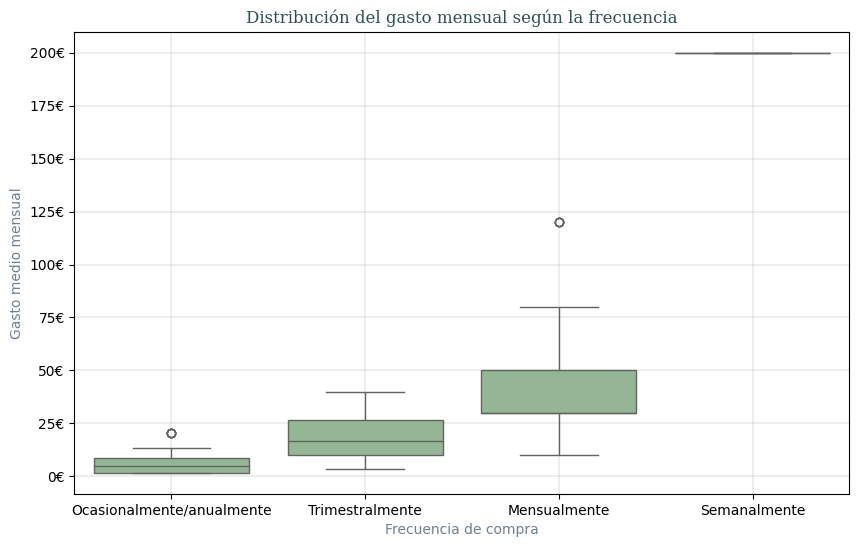

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\dist_gasto_frec.jpg


In [132]:
box_df = consumo.merge(usuarios[['id','frecuencia']], on='id',how='inner')
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=box_df,
    x='frecuencia',
    y='gasto_mensual_avg',
    color='darkseagreen'
)

ax.set_title('Distribución del gasto mensual según la frecuencia', fontdict=font_title)
ax.set_xlabel('Frecuencia de compra', fontdict=font_ax)
ax.set_ylabel('Gasto medio mensual', fontdict=font_ax)
ax.grid(True, linewidth=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}€'.replace(',','.')))
plt.show()
guardar_grafico(fig,'dist_gasto_frec')

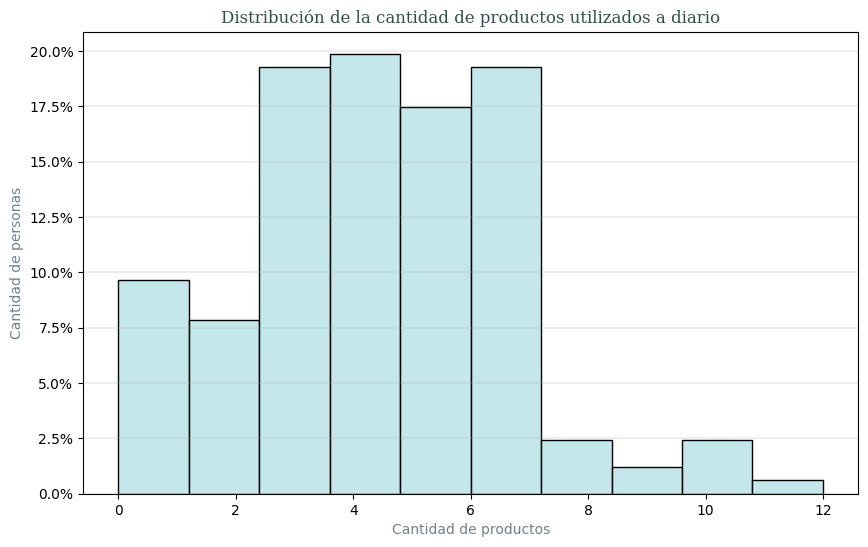

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\hist_cant_productos.jpg


In [133]:
fig, ax = plt.subplots(figsize=(10, 6)) 
sns.histplot(data=consumo, x='cant_productos_uso', bins=10, stat='percent', color='powderblue')
ax.grid(axis='y', linewidth=0.3)
ax.set_xlabel('Cantidad de productos', fontdict=font_ax)
ax.set_ylabel('Cantidad de personas', fontdict=font_ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Distribución de la cantidad de productos utilizados a diario', fontdict=font_title)
plt.show()
guardar_grafico(fig,'hist_cant_productos')

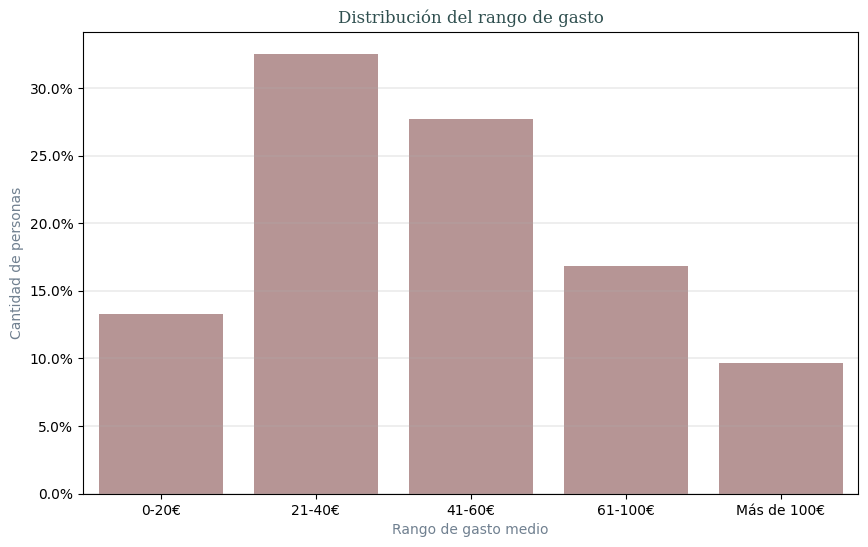

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\bar_rango_gasto.jpg


In [134]:

gasto = (consumo["gasto_avg"].value_counts(normalize=True).mul(100).rename_axis("gasto_avg").reset_index(name='porcentaje'))
gasto = gasto.sort_values(by="gasto_avg")
fig, ax = plt.subplots(figsize=(10, 6)) 
sns.barplot(data=gasto, x='gasto_avg', y='porcentaje', color='rosybrown')
ax.grid(axis='y', linewidth=0.3)
ax.set_xlabel('Rango de gasto medio', fontdict=font_ax)
ax.set_ylabel('Cantidad de personas', fontdict=font_ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Distribución del rango de gasto', fontdict=font_title)
plt.show()
guardar_grafico(fig,'bar_rango_gasto')

#### Perfiles de decisión (PCA+cluster)

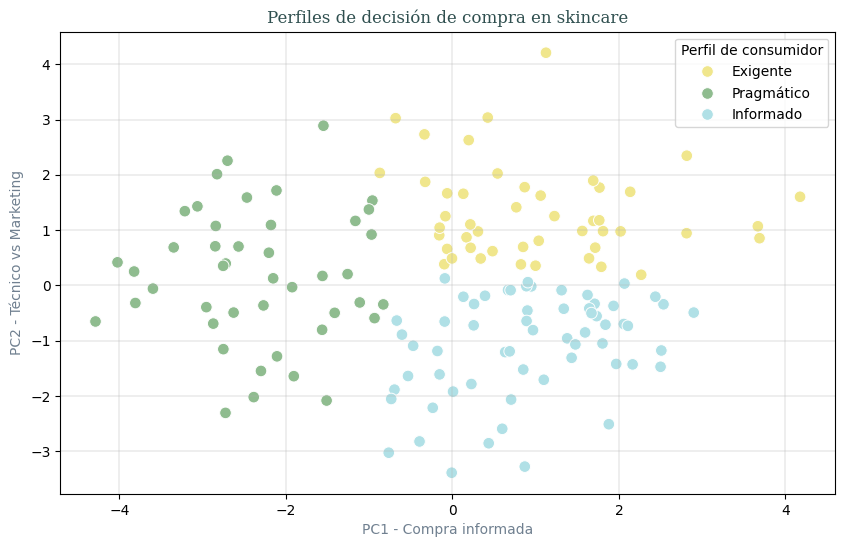

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\segmentacion_perfiles.jpg


In [135]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(
    data=pca,
    x="PC1",
    y="PC2",
    hue="perfil",
    palette=color_perfiles,
    s=70
)

ax.set_title("Perfiles de decisión de compra en skincare", fontdict=font_title)
ax.set_xlabel("PC1 - Compra informada", fontdict=font_ax)
ax.set_ylabel("PC2 - Técnico vs Marketing", fontdict=font_ax)
ax.legend(title="Perfil de consumidor")
ax.grid(True, linewidth=0.3)
plt.show()
guardar_grafico(fig,'segmentacion_perfiles')

#### Comportamiento de consumo por perfil

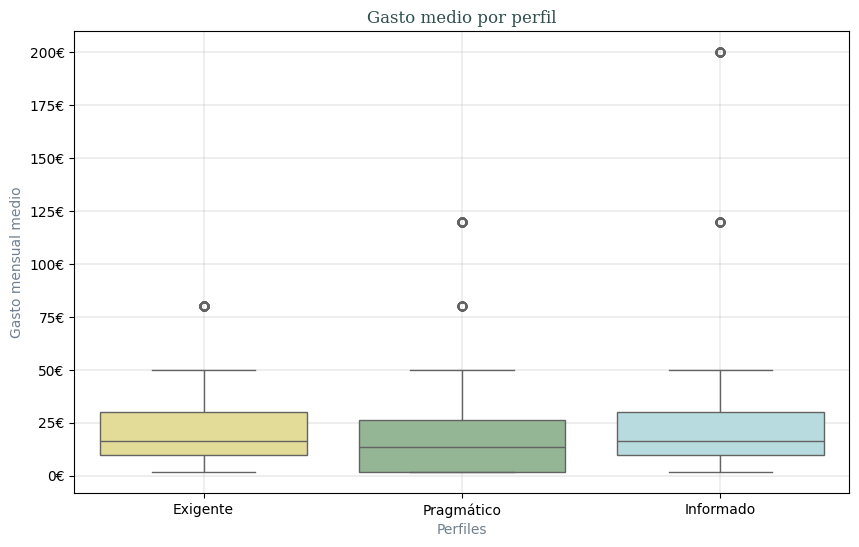

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_gasto.jpg


In [136]:
df_merged = (consumo.merge(clusters, on='id', how='inner')
             .merge(pca, on='cluster', how='left')
             .merge(usuarios[['id','frecuencia','rango_edad','estudios']], on='id', how='left')
             .merge(influencia[['id','preferencia']], on='id', how='left'))

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(
    data=df_merged,
    x="perfil",
    y="gasto_mensual_avg",
    hue="perfil",
    palette=color_perfiles
)
ax.set_title("Gasto medio por perfil", fontdict=font_title)
ax.set_xlabel("Perfiles", fontdict=font_ax)
ax.set_ylabel("Gasto mensual medio", fontdict=font_ax)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}€'.replace(',','.')))
ax.grid(True, linewidth=0.3)
plt.show()
guardar_grafico(fig, 'perfiles_gasto')


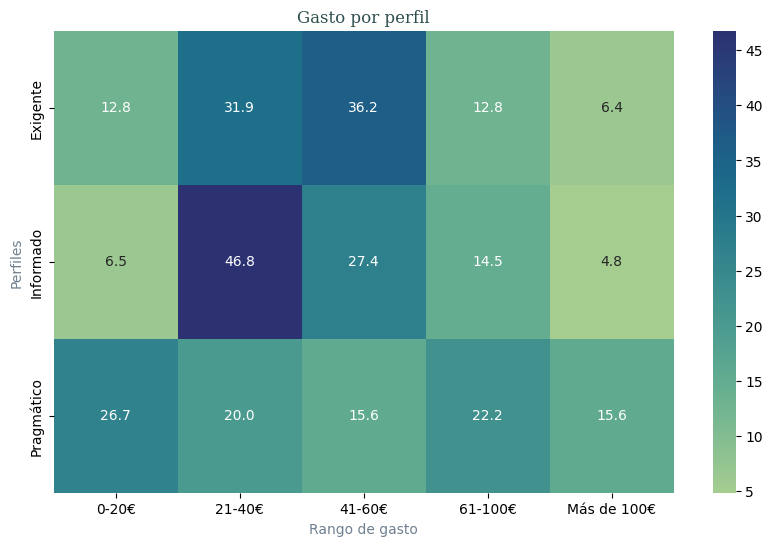

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_gasto.jpg


In [137]:
tabla = pd.crosstab(df_merged["perfil"],df_merged["gasto_avg"], normalize="index")*100

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    data=tabla,
    annot=True,
    fmt='.1f',
    cmap='crest'
)
ax.set_title("Gasto por perfil", fontdict=font_title)
ax.set_xlabel("Rango de gasto", fontdict=font_ax)
ax.set_ylabel("Perfiles", fontdict=font_ax)
plt.show()
guardar_grafico(fig, 'perfiles_gasto')

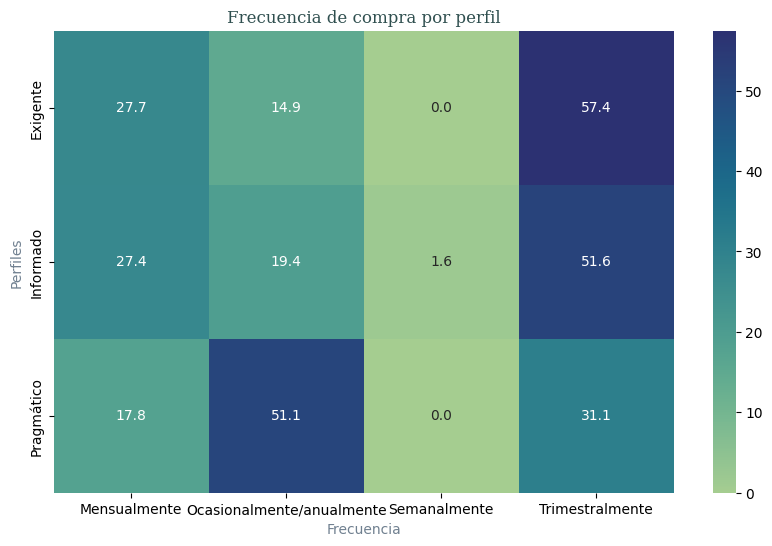

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_frecuencia.jpg


In [138]:
tabla3 = pd.crosstab(df_merged["perfil"],df_merged["frecuencia"], normalize="index")*100

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    data=tabla3,
    annot=True,
    fmt='.1f',
    cmap='crest'
)
ax.set_title("Frecuencia de compra por perfil", fontdict=font_title)
ax.set_xlabel("Frecuencia", fontdict=font_ax)
ax.set_ylabel("Perfiles", fontdict=font_ax)
plt.show()
guardar_grafico(fig,'perfiles_frecuencia')

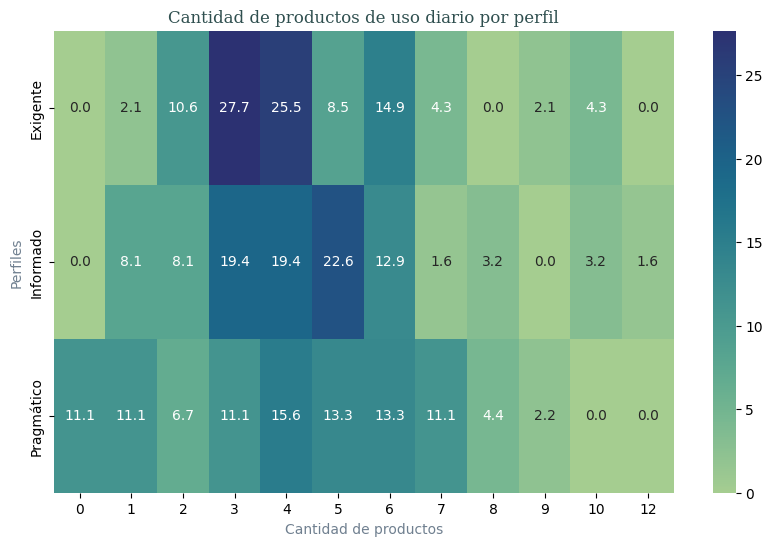

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_productos.jpg


In [139]:
tabla4 = pd.crosstab(df_merged["perfil"],df_merged["cant_productos_uso"], normalize="index")*100

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    data=tabla4,
    annot=True,
    fmt='.1f',
    cmap='crest'
)
ax.set_title("Cantidad de productos de uso diario por perfil", fontdict=font_title)
ax.set_xlabel("Cantidad de productos", fontdict=font_ax)
ax.set_ylabel("Perfiles", fontdict=font_ax)
plt.show()
guardar_grafico(fig,'perfiles_productos')

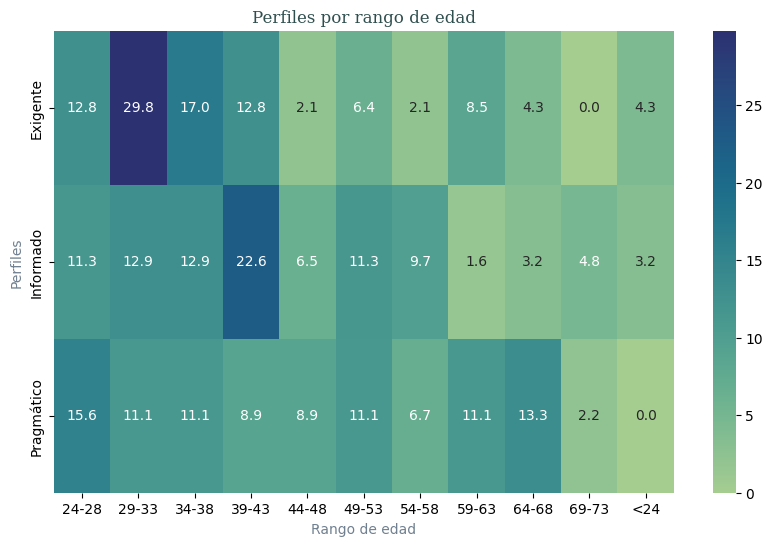

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_edades.jpg


In [140]:
tabla2 = pd.crosstab(df_merged["perfil"],df_merged["rango_edad"], normalize="index")*100

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(
    data=tabla2,
    annot=True,
    fmt='.1f',
    cmap='crest'
)
ax.set_title("Perfiles por rango de edad", fontdict=font_title)
ax.set_xlabel("Rango de edad", fontdict=font_ax)
ax.set_ylabel("Perfiles", fontdict=font_ax)
plt.show()
guardar_grafico(fig, 'perfiles_edades')

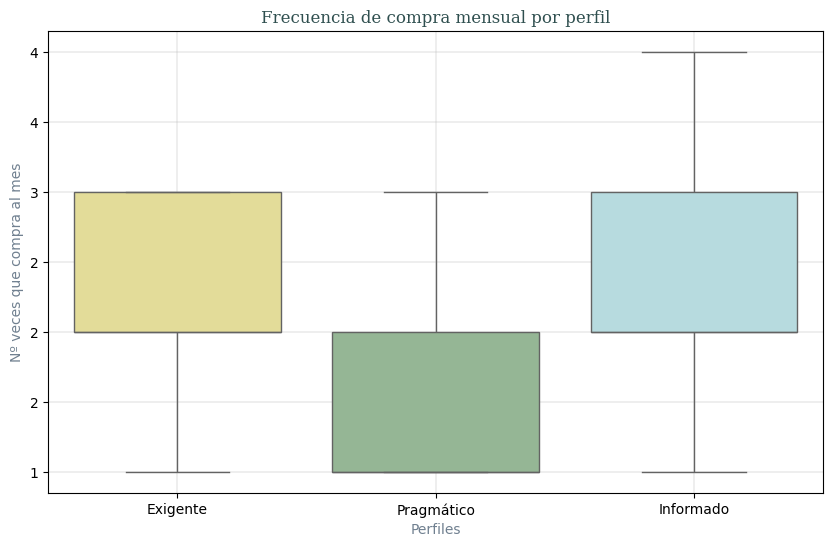

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\perfiles_frec.jpg


In [141]:
fig, ax= plt.subplots(figsize=(10,6))
sns.boxplot(
    data=df_merged,
    x="perfil",
    y="freq_score",
    hue="perfil",
    palette=color_perfiles,
    legend=False
    )
ax.set_title("Frecuencia de compra mensual por perfil", fontdict=font_title)
ax.set_xlabel("Perfiles", fontdict=font_ax)
ax.set_ylabel("Nº veces que compra al mes", fontdict=font_ax)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

ax.grid(True, linewidth=0.3)
plt.show()
guardar_grafico(fig,'perfiles_frec')

#### Posicionamiento consumidor

In [142]:
tabla_posicionamiento = pd.crosstab(
    pca['perfil'],
    influencia['preferencia'],
    normalize='index'
).round(3)

tabla_posicionamiento

preferencia,Dermo,Lujo,Natural,Trendy
perfil,,,,
Exigente,0.617,0.213,0.085,0.085
Informado,0.387,0.145,0.306,0.161
Pragmático,0.289,0.467,0.222,0.022


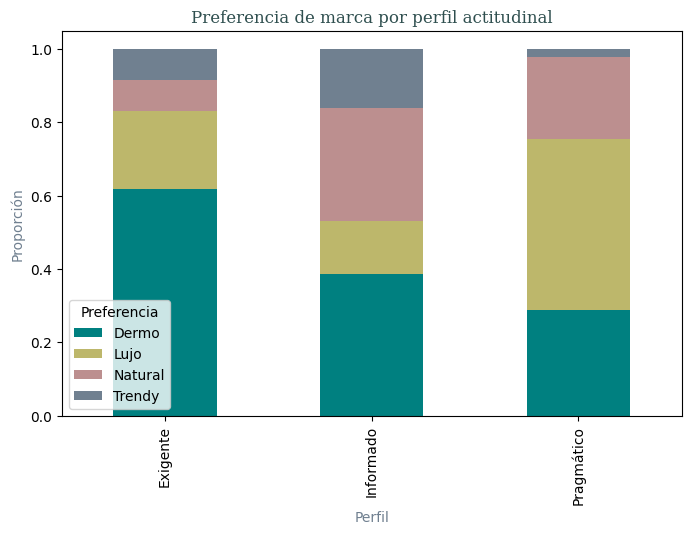

In [143]:
fig = tabla_posicionamiento.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=colores_preferencia
)

plt.title("Preferencia de marca por perfil actitudinal", fontdict=font_title)
plt.ylabel("Proporción", fontdict=font_ax)
plt.xlabel("Perfil", fontdict=font_ax)
plt.legend(title="Preferencia")
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19824\3901846804.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=preferencia, x="preferencia", y="porcentaje",palette=colores_preferencia)


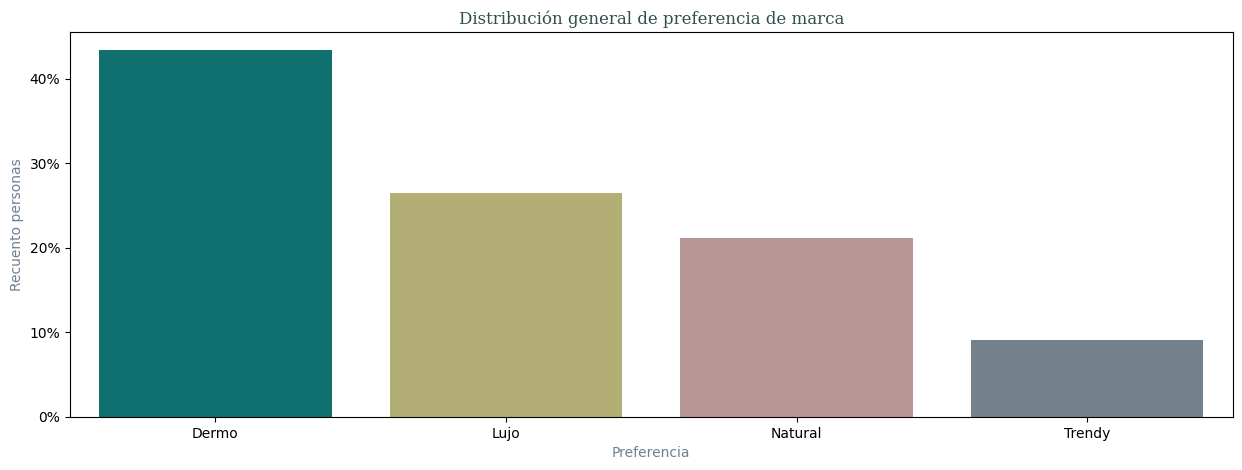

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\preferncia_count.jpg


In [144]:
preferencia = (influencia["preferencia"].value_counts(normalize=True).mul(100).reset_index())
preferencia.columns = ["preferencia", "porcentaje"]

fig, ax = plt.subplots(figsize=(15, 5)) 
sns.barplot(data=preferencia, x="preferencia", y="porcentaje",palette=colores_preferencia)
ax.set_title('Distribución general de preferencia de marca', fontdict=font_title)
ax.set_xlabel('Preferencia', fontdict=font_ax)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}%'.replace(',','.')))
ax.set_ylabel('Recuento personas', fontdict=font_ax)

plt.show()
guardar_grafico(fig,'preferncia_count')